## 1. Setup and changing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, when, array, concat, lit, size, array_contains, expr
)

spark = SparkSession.builder \
    .appName("Weather-KMeans-Apriori") \
    .getOrCreate()

df = spark.read.csv("../data/weather_vn_preprocessed.csv", header=True, inferSchema=True)

assert "region" in df.columns, "Colonne 'region' manquante — relancer preprocessing.py"

df.show(5)
df.printSchema()
print("Regions:", [r["region"] for r in df.select("region").distinct().collect()])


+-------------------+-----------+-----------+--------+--------+--------+----------+----------+-------------+----------+----------+---------+--------------+--------+------+------------+------------+-------------------+------------+----+---+-----+-------+-------+------------------+------------+------------+----+-------+-----------+---------------+---------------+----------+----------+--------------+--------------+
|               time|       city|temperature|temp_min|temp_max|humidity|feels_like|visibility|precipitation|cloudcover|wind_speed|wind_gust|wind_direction|pressure|is_day|weather_code|weather_main|weather_description|weather_icon|hour|day|month|weekday| region|        temp_range|wind_dir_sin|wind_dir_cos|rain|extreme| temp_level| humidity_level| pressure_level|wind_level|temp_lag_1|humidity_lag_1|pressure_lag_1|
+-------------------+-----------+-----------+--------+--------+--------+----------+----------+-------------+----------+----------+---------+--------------+--------+----

## 2. Feature Engineering

In [2]:
df = df.withColumn("temp_range", col("temp_max") - col("temp_min"))

# Seuils cohérents avec preprocessing.py
df = df.withColumn(
    "extreme",
    when(col("temp_max") > 35, "heatwave")
    .when(col("precipitation") > 50, "heavy_rain")
    .when(col("wind_speed") > 40, "storm")
    .otherwise("normal")
)

df.groupBy("region", "extreme").count().orderBy("region", "extreme").show(30)


+-------+----------+-------+
| region|   extreme|  count|
+-------+----------+-------+
|central|  heatwave|  26740|
|central|heavy_rain|      3|
|central|    normal|1035360|
|  north|  heatwave|  28171|
|  north|heavy_rain|     44|
|  north|    normal|1513982|
|  south|  heatwave|   4237|
|  south|    normal|1202376|
+-------+----------+-------+



## 3. Discretization

In [3]:
df = df.withColumn("temp_level",
    when(col("temp_max") < 20, "temp_low")
    .when(col("temp_max") < 30, "temp_medium")
    .otherwise("temp_high")
)
df = df.withColumn("humidity_level",
    when(col("humidity") < 60, "humidity_low")
    .when(col("humidity") < 80, "humidity_medium")
    .otherwise("humidity_high")
)
df = df.withColumn("pressure_level",
    when(col("pressure") < 1000, "pressure_low")
    .when(col("pressure") < 1015, "pressure_normal")
    .otherwise("pressure_high")
)
df = df.withColumn("wind_level",
    when(col("wind_speed") < 10, "wind_low")
    .when(col("wind_speed") < 25, "wind_medium")
    .otherwise("wind_high")
)
# Label binaire pluie — utilisé comme TARGET dans les règles
df = df.withColumn("rain_label",
    when(col("precipitation") > 0, "rain_yes").otherwise("rain_no")
)

df.select("region", "temp_level", "humidity_level", "wind_level",
          "extreme", "rain_label").show(10)


+-------+-----------+---------------+----------+-------+----------+
| region| temp_level| humidity_level|wind_level|extreme|rain_label|
+-------+-----------+---------------+----------+-------+----------+
|central|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  south|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  south|temp_medium|humidity_medium|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|  rain_yes|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|   rain_no|
|  north|temp_medium|  humidity_high|  wind_low| normal|  rain_yes|
+-------+-----------+---------------+----------+-------+----------+
only showing top 10 rows


## 4. K-Means clustering

In [4]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

features = ["temp_max", "temp_min", "humidity", "pressure", "wind_speed", "temp_range"]

assembler = VectorAssembler(inputCols=features, outputCol="features_raw", handleInvalid="skip")
df = assembler.transform(df)

scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True)
df = scaler.fit(df).transform(df)

kmeans_model = KMeans(k=5, seed=42, maxIter=20).fit(df)
df = kmeans_model.transform(df).withColumnRenamed("prediction", "cluster")

df.groupBy("region", "cluster").count().orderBy("region", "cluster").show(30)


+-------+-------+------+
| region|cluster| count|
+-------+-------+------+
|central|      0|107783|
|central|      1|295176|
|central|      3|250167|
|central|      4|408977|
|  north|      0|120170|
|  north|      1|427647|
|  north|      3|336336|
|  north|      4|658044|
|  south|      0|345143|
|  south|      1|175876|
|  south|      2|105362|
|  south|      3|176165|
|  south|      4|404067|
+-------+-------+------+



## 5. Visualisation clusters by region

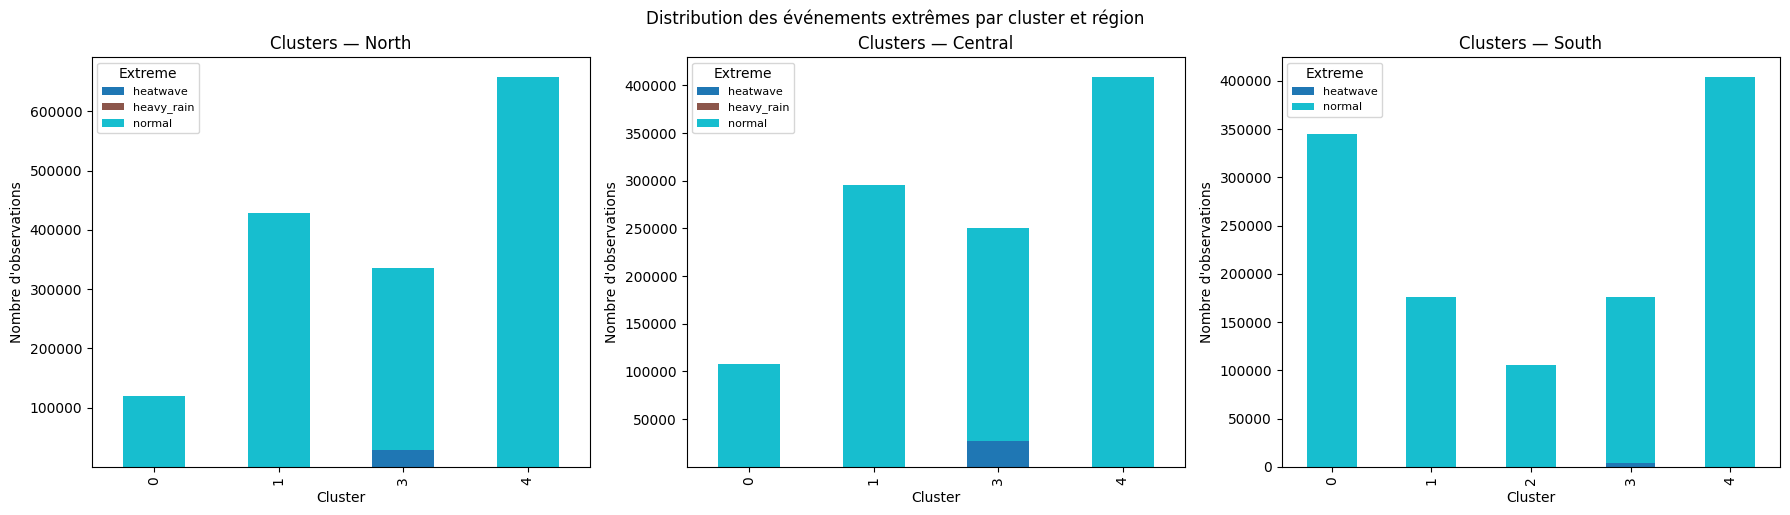

In [ ]:
pdf_cluster = df.groupBy("region", "cluster", "extreme").count().toPandas()  # df global OK ici

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, region in zip(axes, ["north", "central", "south"]):
    sub = pdf_cluster[pdf_cluster["region"] == region]
    pivot = sub.pivot_table(
        index="cluster", columns="extreme", values="count", aggfunc="sum"
    ).fillna(0)
    pivot.plot(kind="bar", stacked=True, ax=ax, colormap="tab10")
    ax.set_title(f"Clusters — {region.capitalize()}")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Nombre d'observations")
    ax.legend(title="Extreme", fontsize=8)

plt.tight_layout()
plt.suptitle("Distribution extremes events by cluster and region", y=1.02)
plt.show()


## 6. Apriori (FPGrowth) — association rules by region

**2 items separates :**
- `items_ctx` : variables climate + cluster (antécédents)
- `items_full` : items_ctx + target (`rain_yes` / label extrême)

Executing FPGrowth on `items_full`, then filter rules **consequence is the target**.


In [6]:
from pyspark.ml.fpm import FPGrowth
from pyspark.sql.functions import array_contains, array_union

# Items contexte : variables prédictives (PAS de region_ car on filtre déjà par région)
df = df.withColumn(
    "items_full",
    array(
        col("temp_level"),
        col("humidity_level"),
        col("wind_level"),
        col("pressure_level"),
        concat(lit("cluster_"), col("cluster").cast("string")),
        col("rain_label"),    # target pluie
        col("extreme")        # target extrême
    )
)

### Split dataset by region

> execute **after** the creation of `items_full`, so that `df_north`, `df_central`, `df_south` inherit all the columns.

In [8]:
# Split APRÈS que toutes les colonnes (items_full, cluster, etc.) sont créées
df_north   = df.filter(col('region') == 'north')
df_central = df.filter(col('region') == 'central')
df_south   = df.filter(col('region') == 'south')

dfs_by_region = {
    'north'  : df_north,
    'central': df_central,
    'south'  : df_south,
}

In [14]:
import os
from pyspark import StorageLevel
from pyspark.sql.functions import array_contains, col, size

all_rules  = {}   # contiendra des Pandas DataFrames (légers)
all_models = {}

TARGET_RAIN    = ["rain_yes"]
TARGET_EXTREME = ["heatwave", "heavy_rain", "storm"]
TARGETS        = TARGET_RAIN + TARGET_EXTREME

# Paramètres plus robustes pour gros volumes
MIN_SUPPORT = 0.01
MIN_CONFIDENCE = 0.2
MAX_RULES = 200
TOP_ITEMSETS = 10

# Ajuster le parallélisme pour éviter des partitions trop grosses
n_parts = max(spark.sparkContext.defaultParallelism * 2, 32)
spark.conf.set("spark.sql.shuffle.partitions", str(n_parts))

# Filtre conséquent pré-calculé
target_filter = None
for t in TARGETS:
    cond = array_contains(col("consequent"), t)
    target_filter = cond if target_filter is None else target_filter | cond

RULES_DIR = "rules_output"
os.makedirs(RULES_DIR, exist_ok=True)

for region in ["north", "central", "south"]:
    print(f"\n{'='*55}")
    print(f"  Région : {region.upper()}")
    print(f"{'='*55}")

    # 1) Isoler ce dont FPGrowth a besoin et persister avec débordement disque
    df_region = (
        dfs_by_region[region]
        .select("items_full")
        .filter(size(col("items_full")) > 1)
        .repartition(n_parts)
        .persist(StorageLevel.MEMORY_AND_DISK)
    )

    tx_count = df_region.count()
    if tx_count == 0:
        print("  >> Aucune transaction exploitable.")
        df_region.unpersist()
        continue
    print(f"  Transactions: {tx_count} | Partitions: {n_parts}")

    # 2) FPGrowth
    fp = FPGrowth(
        itemsCol="items_full",
        minSupport=MIN_SUPPORT,
        minConfidence=MIN_CONFIDENCE,
        numPartitions=n_parts
    )

    try:
        fp_model = fp.fit(df_region)
    except Exception as e:
        print(f"  ⚠ FPGrowth échoué : {e}")
        df_region.unpersist()
        continue

    print(f"  >> Top {TOP_ITEMSETS} itemsets fréquents :")
    fp_model.freqItemsets \
        .orderBy(col("freq").desc()) \
        .limit(TOP_ITEMSETS) \
        .show(truncate=False)

    # 3) Règles ciblées (Spark d'abord), puis conversion limitée vers Pandas
    target_rules_df = (
        fp_model.associationRules
        .orderBy(col("lift").desc())
        .limit(MAX_RULES)
    )

    n = target_rules_df.count()
    print(f"  >> {n} règles prédisant pluie / extrême")
    print("Total itemsets:")
    print(fp_model.freqItemsets.count())
    target_rules_df.select("antecedent", "consequent", "support", "confidence", "lift") \
        .show(15, truncate=False)

    target_rules_pd = target_rules_df.toPandas()

    # Sauvegarder sur disque (utile si kernel redémarre)
    out_path = os.path.join(RULES_DIR, f"rules_{region}.csv")
    target_rules_pd.to_csv(out_path, index=False)
    print(f"  >> Sauvegardé : {out_path}")

    all_rules[region] = target_rules_pd
    all_models[region] = fp_model

    # 4) Libérer la mémoire avant la prochaine région
    df_region.unpersist()
    print(f"  >> Mémoire libérée pour {region}.")

print("\n✓ FPGrowth terminé. Règles disponibles dans all_rules[region] (Pandas).")


  Région : NORTH
  Transactions: 1542197 | Partitions: 32
  >> Top 10 itemsets fréquents :
+-----------------------------------+-------+
|items                              |freq   |
+-----------------------------------+-------+
|[wind_low]                         |1538160|
|[normal]                           |1513982|
|[normal, wind_low]                 |1509945|
|[rain_no]                          |1270301|
|[rain_no, wind_low]                |1268909|
|[pressure_normal]                  |1265693|
|[pressure_normal, wind_low]        |1262822|
|[pressure_normal, normal]          |1255100|
|[pressure_normal, normal, wind_low]|1252229|
|[rain_no, normal]                  |1244752|
+-----------------------------------+-------+

  >> 200 règles prédisant pluie / extrême
Total itemsets:
1155
+------------------------------------------------------------+----------+--------------------+-------------------+------------------+
|antecedent                                                  |cons

## 7. Visualisation — Support / Confidence / Lift by region

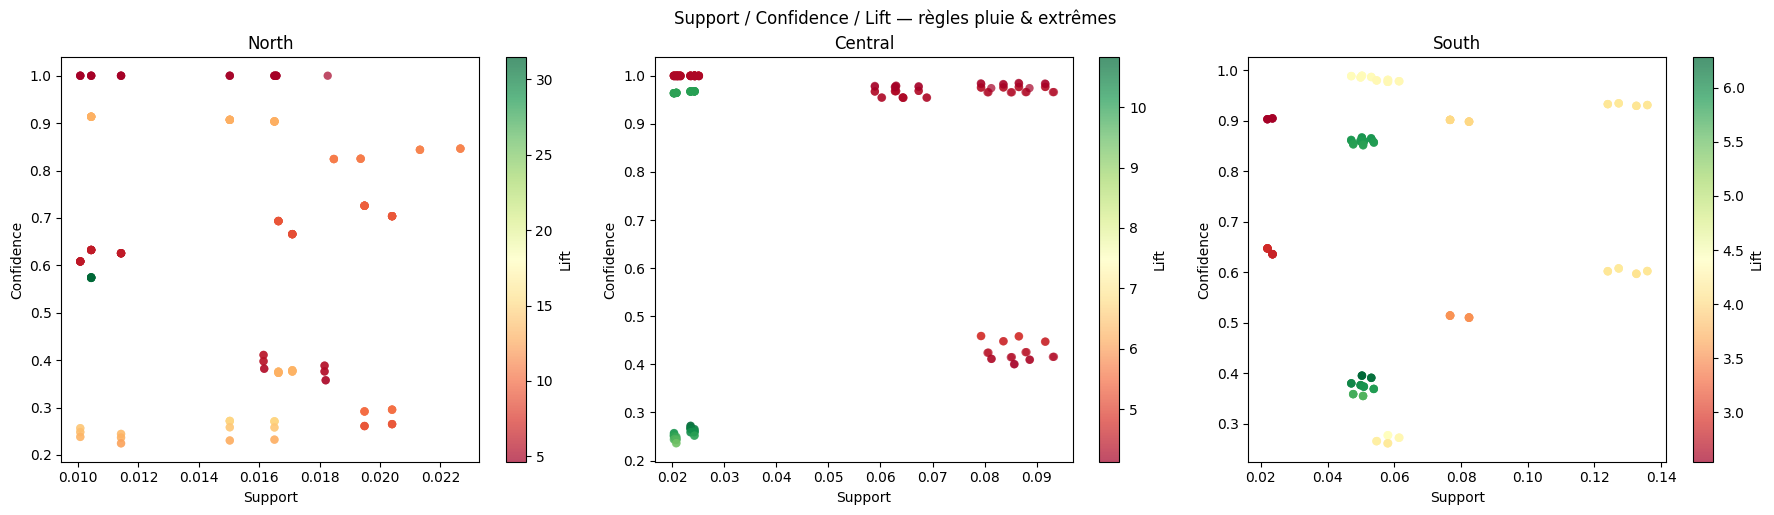

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, region in zip(axes, ["north", "central", "south"]):
    pdf_r = all_rules.get(region)
    if pdf_r is None or pdf_r.empty:
        ax.text(0.5, 0.5, "Aucune règle\ntrouvée", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(region.capitalize())
        continue
    sc = ax.scatter(pdf_r["support"], pdf_r["confidence"],
                    c=pdf_r["lift"], cmap="RdYlGn", alpha=0.7, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Lift")
    ax.set_title(f"{region.capitalize()}")
    ax.set_xlabel("Support")
    ax.set_ylabel("Confidence")

plt.tight_layout()
plt.suptitle("Support / Confidence / Lift — règles pluie & extrêmes", y=1.02)
plt.show()


## 8. Top 10 règles par Lift — comparaison inter-régions

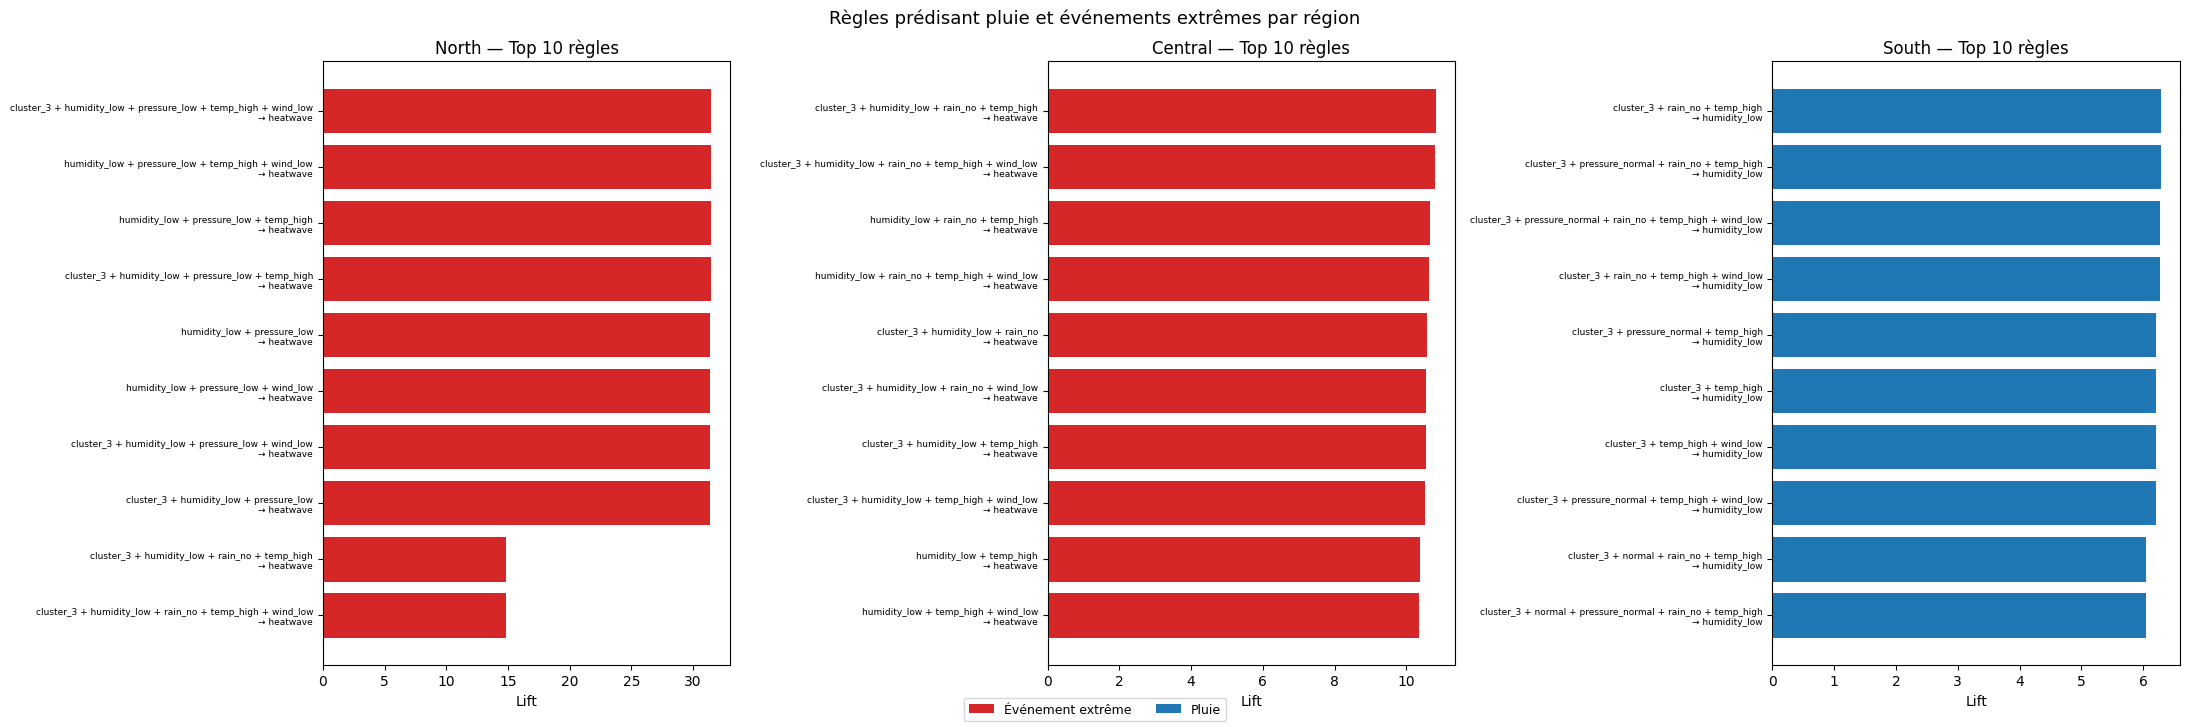

In [16]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, region in zip(axes, ["north", "central", "south"]):
    top = all_rules.get(region)
    if top is None or top.empty:
        ax.text(0.5, 0.5, "Aucune règle", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(region.capitalize())
        continue

    top = top.head(10)  # déjà trié par lift desc, déjà Pandas

    labels = [
        f"{' + '.join(sorted(a))}\n→ {' + '.join(sorted(c))}"
        for a, c in zip(top["antecedent"], top["consequent"])
    ]
    colors = ["#d62728" if any(t in str(c) for t in TARGET_EXTREME) else "#1f77b4"
              for c in top["consequent"]]

    ax.barh(range(len(top)), top["lift"], color=colors)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(labels, fontsize=6.5)
    ax.set_xlabel("Lift")
    ax.set_title(f"{region.capitalize()} — Top 10 règles")
    ax.invert_yaxis()

legend_elements = [
    Patch(facecolor="#d62728", label="Événement extrême"),
    Patch(facecolor="#1f77b4", label="Pluie")
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=9)
plt.tight_layout()
plt.suptitle("Règles prédisant pluie et événements extrêmes par région", y=1.02, fontsize=13)
plt.show()


#9. Heatmap: Most frequent antecedents by region and target


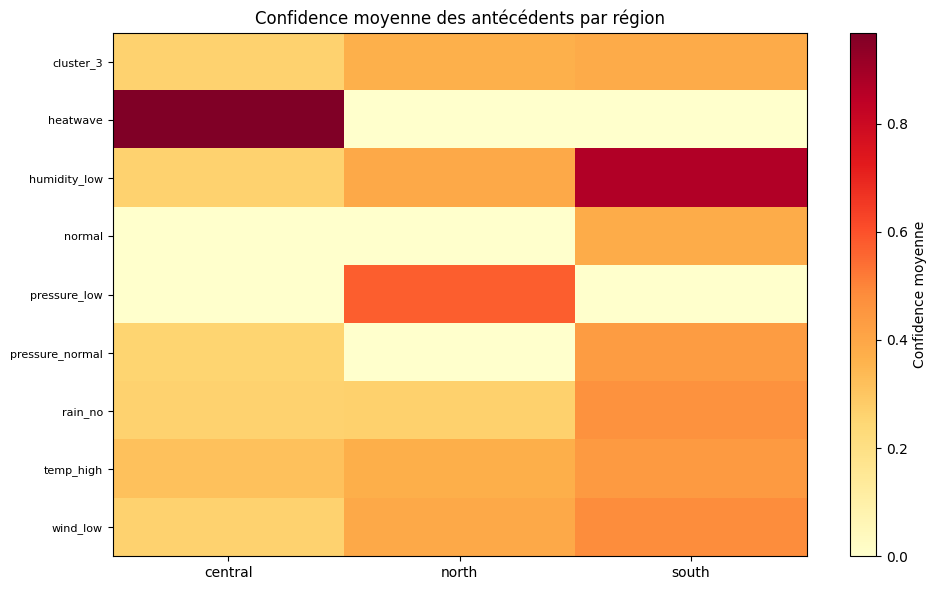

In [17]:
import pandas as pd

records = []
for region in ["north", "central", "south"]:
    top = all_rules.get(region)
    if top is None or top.empty:
        continue
    for _, row in top.head(20).iterrows():
        for item in row["antecedent"]:
            for cons in row["consequent"]:
                records.append({
                    "region": region,
                    "antecedent_item": item,
                    "consequent": cons,
                    "lift": row["lift"],
                    "confidence": row["confidence"]
                })

df_vis = pd.DataFrame(records)

if not df_vis.empty:
    pivot = df_vis.groupby(["region", "antecedent_item"])["confidence"].mean().unstack(0).fillna(0)
    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot) * 0.4)))
    im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=8)
    plt.colorbar(im, ax=ax, label="Confidence moyenne")
    ax.set_title("Confidence moyenne des antécédents par région")
    plt.tight_layout()
    plt.show()
else:
    print("Pas assez de règles pour la heatmap.")
